In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("24-medical_cost.csv")

In [3]:
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Id        1338 non-null   int64  
 1   age       1338 non-null   int64  
 2   sex       1338 non-null   object 
 3   bmi       1338 non-null   float64
 4   children  1338 non-null   int64  
 5   smoker    1338 non-null   object 
 6   region    1338 non-null   object 
 7   charges   1338 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 83.8+ KB


In [5]:
df.isna().sum()

Id          0
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.describe()

,Id,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,669.500000,39.207025,30.663397,1.094918,13270.422265
std,386.391641,14.049960,6.098187,1.205493,12110.011237
min,1.000000,18.000000,15.960000,0.000000,1121.873900
25%,335.250000,27.000000,26.296250,0.000000,4740.287150
50%,669.500000,39.000000,30.400000,1.000000,9382.033000
75%,1003.750000,51.000000,34.693750,2.000000,16639.912515
max,1338.000000,64.000000,53.130000,5.000000,63770.428010


<Axes: xlabel='sex', ylabel='count'>

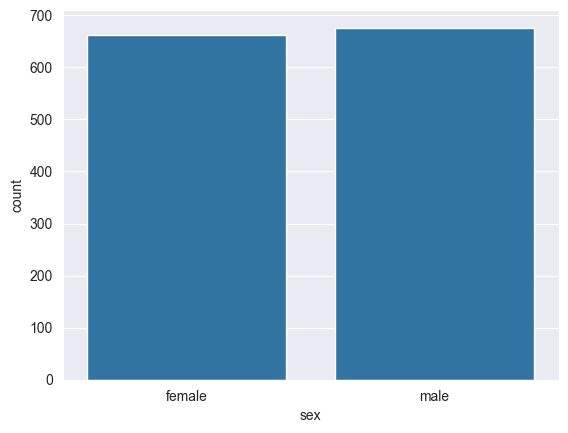

In [7]:
sns.countplot(data=df,x="sex")

<Axes: xlabel='region', ylabel='count'>

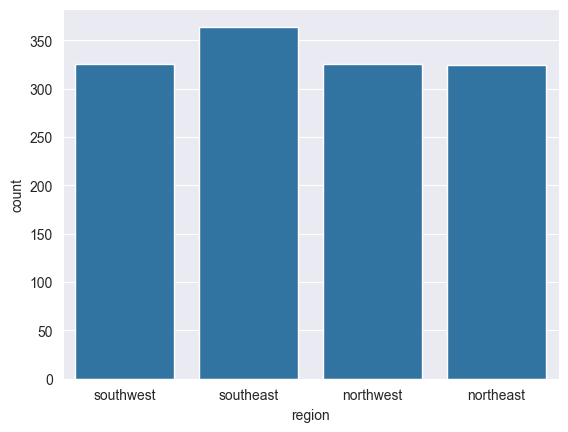

In [9]:
sns.countplot(df,x="region")

<Axes: xlabel='age', ylabel='charges'>

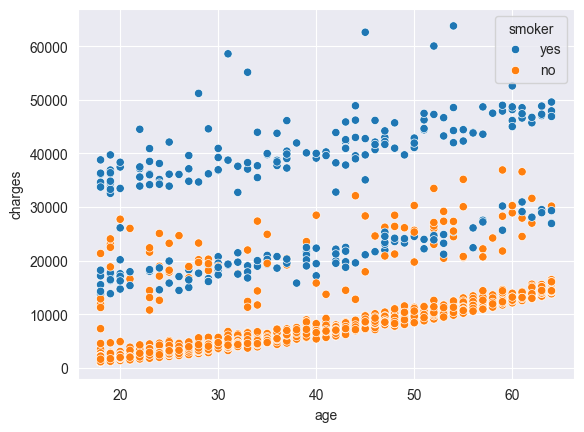

In [14]:
sns.scatterplot(df,x="age",y="charges",hue="smoker")

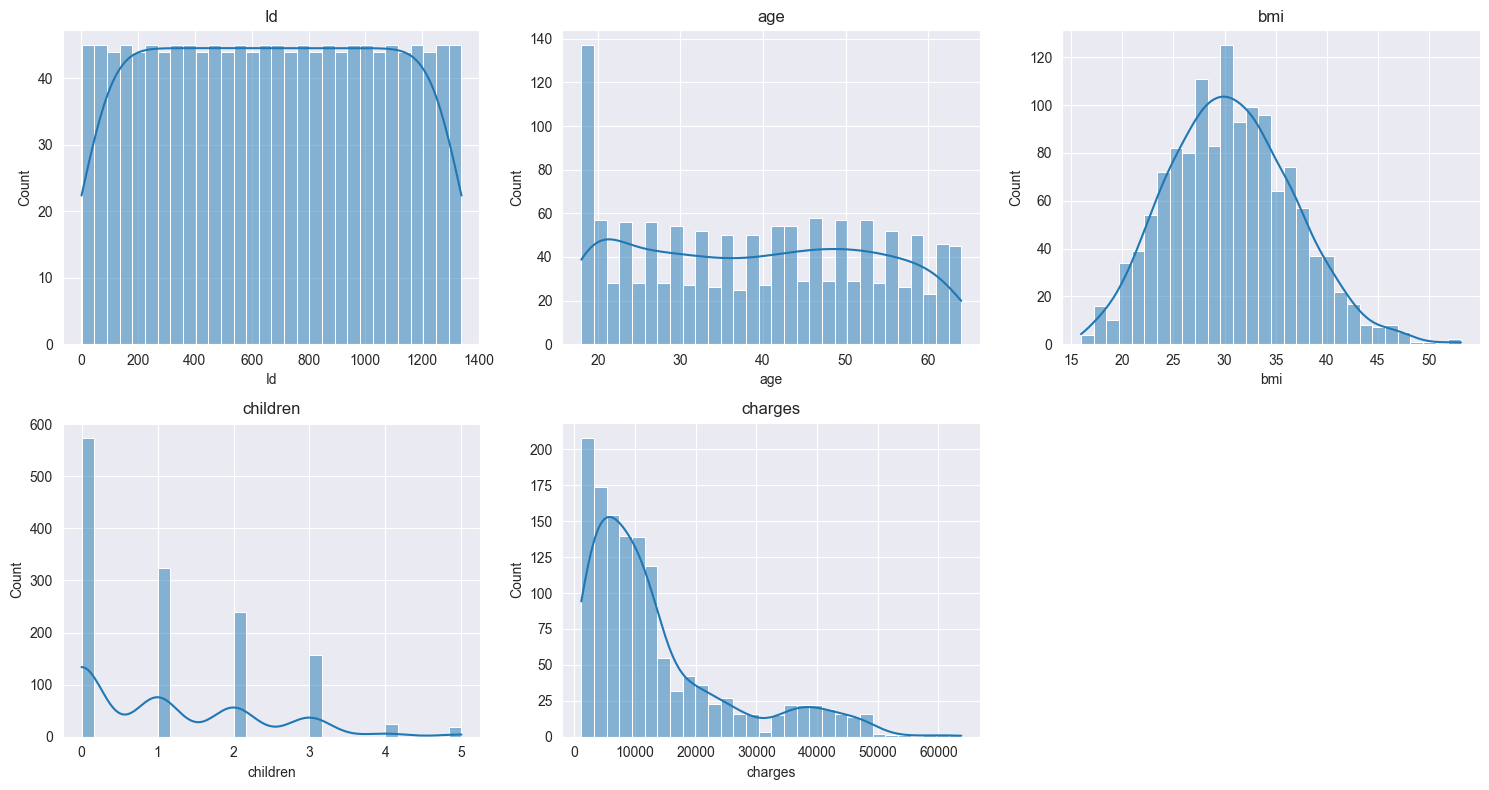

In [8]:
import math

def plot_all_histograms(df,title_prefix = ""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))
    for x, col in enumerate(num_cols,1):
        plt.subplot(n_rows, n_cols, x)
        sns.histplot(df[col], bins=30,kde=True)
        plt.title(f"{title_prefix}{col}" )

    plt.tight_layout()
    plt.show()

plot_all_histograms(df)

In [16]:
df.drop("Id", axis=1, inplace=True)

In [17]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [18]:
df["sex"] = df["sex"].map({"male":1, "female":0})
df["smoker"] = df["smoker"].map({"yes":1, "no":0})

In [19]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [20]:
df["sex"].value_counts()

sex
1    676
0    662
Name: count, dtype: int64

In [21]:
df["smoker"].value_counts()


smoker
0    1064
1     274
Name: count, dtype: int64

In [22]:
#one hot encoding
X = df.drop("charges", axis=1)
y = df["charges"]

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [25]:
categorical_cols = ["region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ],remainder="passthrough",
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [27]:
from lightgbm import LGBMRegressor
model = LGBMRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000143 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 321
[LightGBM] [Info] Number of data points in the train set: 1003, number of used features: 9
[LightGBM] [Info] Start training from score 13374.181390


C:\Users\cemal\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [28]:
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

print("mean_squared_error",mean_squared_error(y_test, y_pred))
print("r2_score",r2_score(y_test, y_pred))
print("mean_absolute_error",mean_absolute_error(y_test, y_pred))

mean_squared_error 18303899.922901437
r2_score 0.8729139056809867
mean_absolute_error 2695.1432117768054


In [29]:
#hyperparameter tuning
param_grid = {
    "learning_rate": [0.01,0.05,0.1],
    "num_leaves": [31,50,70],
    "max_depth": [3,4,5,7],
    "n_estimators": [100,200,500,1000],
    "min_child_samples ": [10,20,30,50],
    "subsample": [0.6,0.8,0.10],
    "colsample_bytree": [0.6,0.8,0.1,1,2],
    "reg_alpha": [0,0.1,0.2,0.3],
    "reg_lambda": [0,0.1,0.2,0.3]
}

In [30]:
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings("ignore")


In [31]:
random_search = RandomizedSearchCV(
    estimator=LGBMRegressor(),
    param_distributions=param_grid,
    cv =5,
    verbose=0,
    n_jobs=-1,
    scoring="neg_mean_squared_error",
)
random_search.fit(X_train, y_train)
y_pred2 = random_search.predict(X_test)

[LightGBM] [Warning] min_child_samples is set=20, min_child_samples= will be ignored. Current value: min_child_samples=20
[LightGBM] [Warning] Unknown parameter: 50
[LightGBM] [Warning] min_child_samples is set=20, min_child_samples= will be ignored. Current value: min_child_samples=20
[LightGBM] [Warning] Unknown parameter: 50
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000184 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 321
[LightGBM] [Info] Number of data points in the train set: 1003, number of used features: 9
[LightGBM] [Info] Start training from score 13374.181390
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fur

In [33]:
random_search.best_params_

{'subsample': 0.1,
 'reg_lambda': 0.2,
 'reg_alpha': 0.1,
 'num_leaves': 50,
 'n_estimators': 200,
 'min_child_samples ': 50,
 'max_depth': 3,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

In [32]:
print("mean_squared_error",mean_squared_error(y_test, y_pred2))
print("r2_score",r2_score(y_test, y_pred2))
print("mean_absolute_error",mean_absolute_error(y_test, y_pred2))

mean_squared_error 13800208.864417907
r2_score 0.9041835536277619
mean_absolute_error 2189.6556603290614


In [35]:
#transformation

In [36]:
from scipy.stats import boxcox

In [38]:
y_train_transformed, lambda_y = boxcox(y_train)

In [39]:
model = LGBMRegressor()
model.fit(X_train, y_train_transformed)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 321
[LightGBM] [Info] Number of data points in the train set: 1003, number of used features: 9
[LightGBM] [Info] Start training from score 12.319019


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [41]:
y_pred_transformed = model.predict(X_test)

In [40]:
def inverse_boxcox(y,lambda_):
    if lambda_ ==0 :
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1/ lambda_)

In [42]:
y_pred_origin = inverse_boxcox(y_pred_transformed,lambda_y)

In [43]:
print("mean_squared_error",mean_squared_error(y_test, y_pred_origin))
print("r2_score",r2_score(y_test, y_pred_origin))
print("mean_absolute_error",mean_absolute_error(y_test, y_pred_origin))

mean_squared_error 14790304.834810536
r2_score 0.8973092027840514
mean_absolute_error 2077.6778994868087
